In [1]:
# --- Auto-reload packages when code changes (no kernel restart needed) ---
try:
    # For Jupyter/IPython environments
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
    print("🔄 Autoreload enabled: code changes will be auto-reloaded!")
except Exception as e:
    print("⚠️ Could not enable autoreload (not in IPython/Jupyter?):", e)


🔄 Autoreload enabled: code changes will be auto-reloaded!


In [2]:
# Clean solution: Auto-add project root to path
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['image.cmap'] = 'cividis'

# Get the project root (parent directory of examples/)
project_root = os.path.dirname(os.path.abspath('.'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Now import everything cleanly
from DynaSD import GIN, NDD, LiNDDA, MINDD, IMPRINT, WVNT, LiRNDDA, ABSSLP, HFER

import numpy as np
import pandas as pd
import scipy as sc

from tests.synthetic_data_generator import SyntheticSeizureGenerator

print("✅ DynaSD imported successfully!")
print(f"📁 Project root: {project_root}")
print(f"🐍 Using Python: {sys.executable}")

# Verify the imports work
print(f"📦 GIN class: {GIN}")
print(f"📦 NDD class: {NDD}")

✅ DynaSD imported successfully!
📁 Project root: /Users/haoershi/Downloads/UPenn/00_CNT/01_Saurabh_ICU_EEG/02_Code/SZ_detect_model_test/DynaSD-wo_dev
🐍 Using Python: /opt/miniconda3/bin/python
📦 GIN class: <class 'DynaSD.GIN.GIN'>
📦 NDD class: <class 'DynaSD.NDD.NDD'>


In [3]:
fs = 256
generator = SyntheticSeizureGenerator(fs=fs, random_seed=42)

data,sz_start,sz_end = generator.generate_combined_signal(baseline_duration=20, seizure_duration=10, seizure_type='polyspike', n_channels=2, focal_channels=list(range(8)), transition_duration=0)


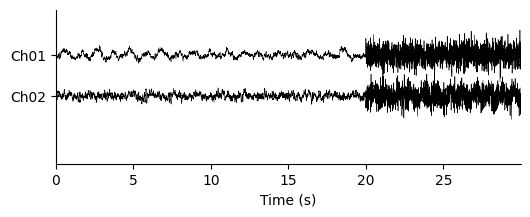

In [4]:
from example_utils import plot_iEEG_data
plot_iEEG_data(data,fs=fs,fig_size=(6,2))
plt.show()

In [5]:
sequence_length = 5
forecast_length = 4

model = LiNDDA(closeform=True,
sequence_length = sequence_length,
forecast_length=forecast_length,
w_stride=0.5,
w_size=1)

sequence_length = 12
forecast_length = 1
# model = GIN(
#     sequence_length=sequence_length,
#     forecast_length=forecast_length,
#     num_epochs=100,
#     batch_size=128,
#     early_stopping=True,
#     hidden_size=10,
#     w_stride=0.5,
#     w_size=1)

model.fit(data.iloc[:fs*10,:])

  Model: SkLinearForecaster_2ch_5seq
  Using sklearn LinearRegression (closeform=True)
Creating 2555 sequences using vectorized operations (stride=1)
Creating 638 sequences using vectorized operations (stride=4)


In [8]:
ndd = model(data)

prob_times = model.get_win_times(len(data))
onset_idx = np.argmin(np.abs(prob_times-sz_start))//2

Creating 1918 sequences using vectorized operations (stride=4)


Using cached sequences


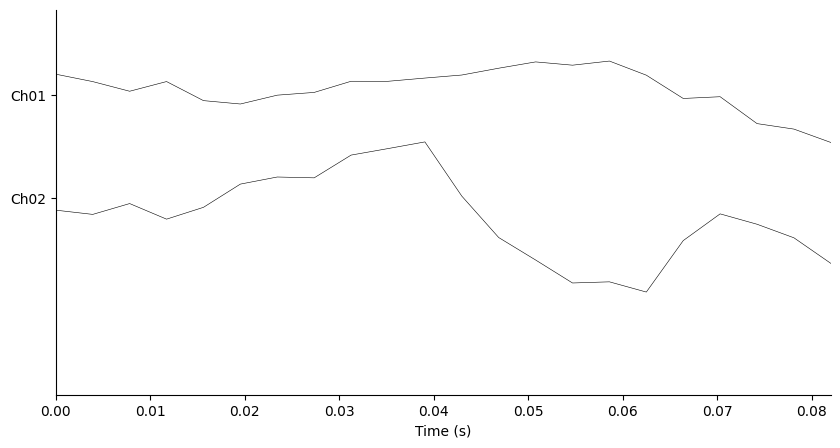

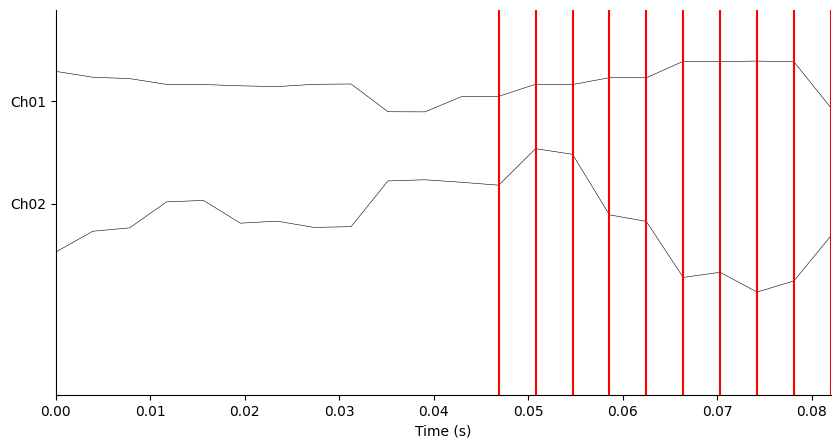

In [23]:
# forecast_length = 32
# model.forecast_length = forecast_length
x = model.predict(data.iloc[:,:])
data_plot = data.iloc[np.isnan(x).sum(axis=1)==0,:].copy()
s = 10*fs
length = forecast_length*10 + sequence_length
plot_iEEG_data(data_plot.iloc[s:s+length,:],fs=fs,fig_size=(10,5))
plt.show()
fig,ax = plot_iEEG_data(pd.DataFrame(x,columns=data.columns).iloc[s:s+length,:],fs=fs,fig_size=(10,5))
for v in range(10):
    ax.axvline((v*forecast_length+sequence_length)/fs,color='r')
plt.show()

Using cached sequences
==============================NDD (MSE)==============================


<Figure size 600x150 with 0 Axes>

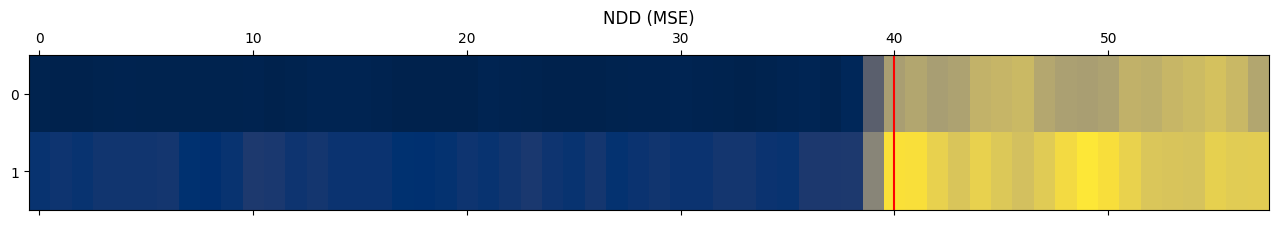

==============================MSE_Z==============================


<Figure size 600x150 with 0 Axes>

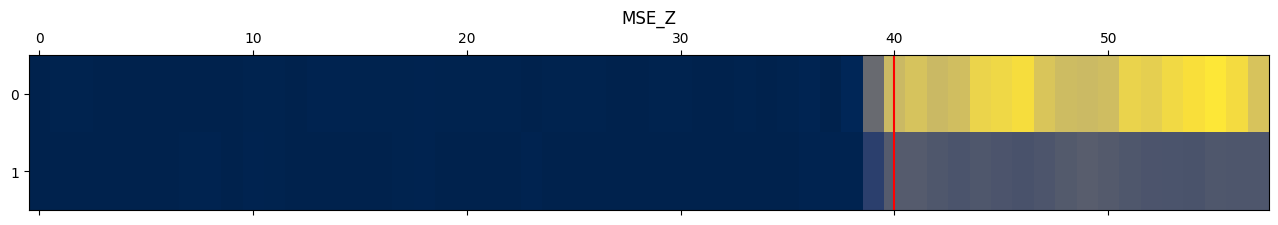

Using cached sequences


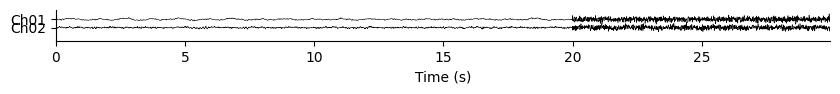

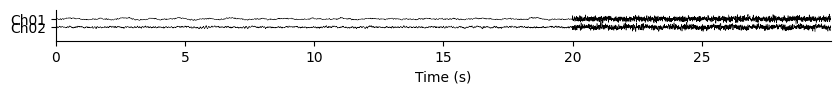

====================Baseline $R^2$====================
0.9111706429330545


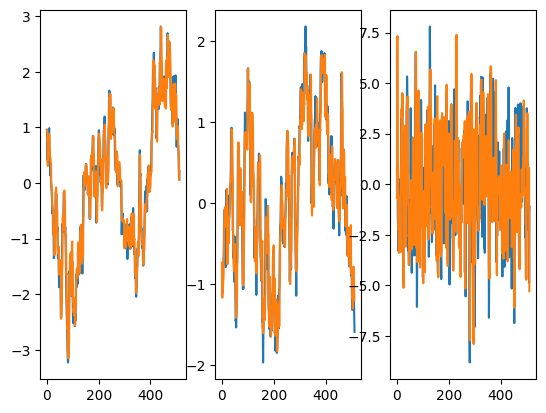

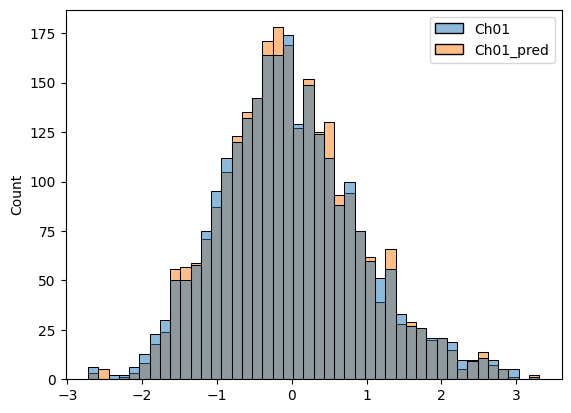

In [24]:
prob_times = model.get_win_times(len(data))
onset_idx = np.argmin(np.abs(prob_times-sz_start))//2

ndd = model(data)
mse_z = model.mse_z_df.to_numpy()
train_idx = len(ndd)

mat_strs = ['NDD (MSE)','MSE_Z']
for i,mat in enumerate([ndd,np.abs(mse_z)]):
    print('='*30 + mat_strs[i] + '='*30)
    plt.figure(figsize=(6,1.5));
    plt.matshow(mat.T,aspect='auto');
    plt.title(mat_strs[i]);
    plt.axvline(x=onset_idx*2,color='r');
    plt.show();

x = model.predict(data)
nan_mask = np.isnan(x).sum(axis=1)==0
plot_iEEG_data(pd.DataFrame(x,columns=data.columns).loc[nan_mask,:],fs=fs)
plot_iEEG_data(data,fs=fs)
plt.show()
print('='*20 + 'Baseline $R^2$' + '='*20)
print(np.corrcoef(x[fs*10:fs*20,:].reshape(1,-1),data.iloc[fs*10:fs*20,:].to_numpy().reshape(1,-1))[0,1])
s = 5*fs
plt.subplot(1,3,1)
plt.plot(data.loc[s:s+512,['Ch01']].values)
plt.plot(x[s:s+512,0])
s = 15*fs
plt.subplot(1,3,2)
plt.plot(data.loc[s:s+512,['Ch01']].values)
plt.plot(x[s:s+512,0])
s = 20*fs
plt.subplot(1,3,3)
plt.plot(data.loc[s:s+512,['Ch01']].values)
plt.plot(x[s:s+512,0])
plt.show()

sns.histplot((data['Ch01'][10*fs:20*fs],pd.DataFrame(x,columns=data.columns+'_pred').loc[10*fs:20*fs,'Ch01_pred']))
plt.show()


In [28]:
model.get_threshold(model.mse_df,method='automedian')

/Users/wojemann/Documents/CNT/DynaSD/DynaSD/base.py:106: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = sz_prob.iloc[:,i_ch].fillna(method='ffill').to_numpy()
/Users/wojemann/Documents/CNT/DynaSD/DynaSD/base.py:106: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = sz_prob.iloc[:,i_ch].fillna(method='ffill').to_numpy()


np.float64(0.619472157163767)

In [29]:
clf = IMPRINT(fs=fs)
clf.fit(data.iloc[:fs*10,:])
imp_thresh = clf.get_threshold()
imp = clf(data)
imp_times = clf.get_win_times(len(data))

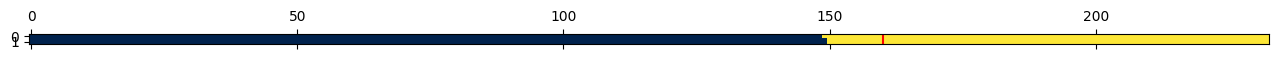

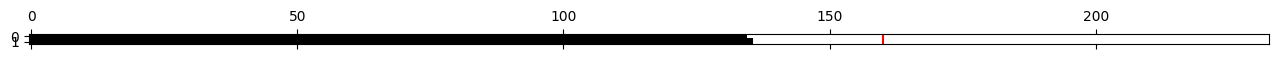

In [30]:
plt.matshow(sc.ndimage.median_filter(imp,size=20,mode='nearest',axes=0).T>imp_thresh)
imp_onset_idx = np.argmin(np.abs(imp_times-sz_start))
plt.axvline(x=imp_onset_idx,color='r')
_,imp_sz_clf = clf.get_onset_and_spread(imp.iloc[:,:],ret_smooth_mat=True)
plt.matshow(imp_sz_clf.T,cmap='gray')
plt.axvline(x=imp_onset_idx,color='r')

/Users/wojemann/Documents/CNT/DynaSD/dynasd_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/wojemann/Documents/CNT/DynaSD/dynasd_env/lib/python3.13/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Successfully loaded WaveNet model from ../checkpoints/WaveNet/v111.hdf5


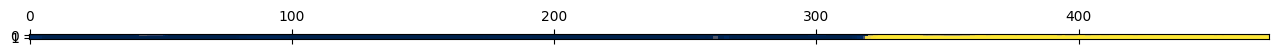

In [31]:
wvnt = WVNT(w_size=1,w_stride=0.125,verbose=False,batch_size=512)
wvnt.fit(data.iloc[:fs*10,:])
wave = wvnt(data)
plt.matshow(sc.ndimage.median_filter(wave,size=20,mode='nearest',axes=0).T)

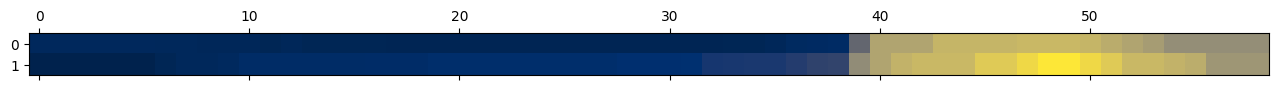

In [32]:
clf = HFER(fs=fs)
clf.fit(data.iloc[:fs*10,:])
sz_prob = clf(data)
plt.matshow(sc.ndimage.median_filter(sz_prob,size=20,mode='nearest',axes=0).T)